# Time Series on Air Temperture

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the data
df = pd.read_csv("E:/Datasets/PRAICP-1003-AirTempTS/Data/surface-air-temperature-monthly-mean.csv")


In [3]:
# Basic check on data
df.head()

,month,mean_temp
0,1982-01,25.9
1,1982-02,27.1
2,1982-03,27.2
3,1982-04,27.0
4,1982-05,28.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   month      462 non-null    object 
 1   mean_temp  462 non-null    float64
dtypes: float64(1), object(1)
memory usage: 7.3+ KB


In [5]:
df.isnull().sum()

month        0
mean_temp    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,mean_temp
count,462.000000
mean,27.665152
std,0.808186
min,25.400000
25%,27.100000
50%,27.700000
75%,28.300000
max,29.500000


In [8]:
# formatting datatime index
df['month'] = pd.to_datetime(df['month'])
df.set_index('month', inplace=True)
df = df.sort_index()

In [9]:
df.index

DatetimeIndex(['1982-01-01', '1982-02-01', '1982-03-01', '1982-04-01',
               '1982-05-01', '1982-06-01', '1982-07-01', '1982-08-01',
               '1982-09-01', '1982-10-01',
               ...
               '2019-09-01', '2019-10-01', '2019-11-01', '2019-12-01',
               '2020-01-01', '2020-02-01', '2020-03-01', '2020-04-01',
               '2020-05-01', '2020-06-01'],
              dtype='datetime64[ns]', name='month', length=462, freq=None)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 462 entries, 1982-01-01 to 2020-06-01
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   mean_temp  462 non-null    float64
dtypes: float64(1)
memory usage: 7.2 KB


<Axes: ylabel='mean_temp'>

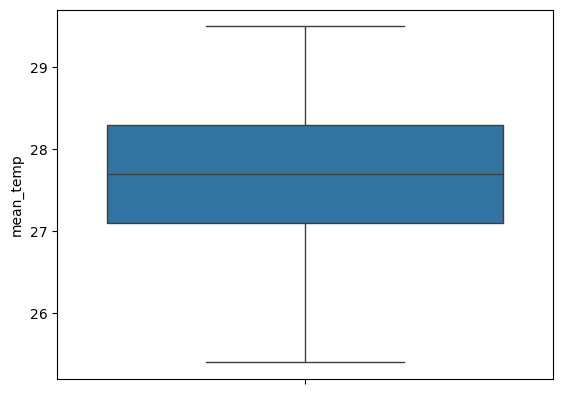

In [11]:
sns.boxplot(data=df['mean_temp'])

<Axes: xlabel='month', ylabel='mean_temp'>

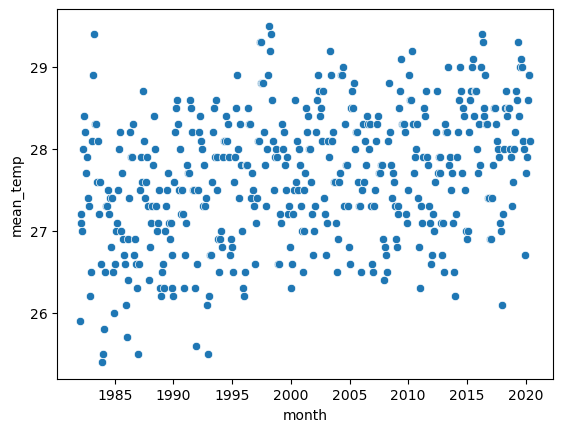

In [12]:
sns.scatterplot(data=df['mean_temp'])

<Axes: xlabel='mean_temp', ylabel='Count'>

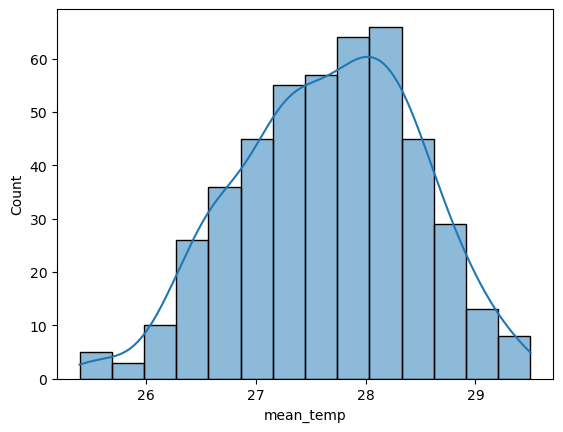

In [13]:
sns.histplot(data=df['mean_temp'],kde=True)

## Model Creation

In [14]:
# imports
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

In [15]:
#Checking stationarity
result = adfuller(df['mean_temp'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -4.265046395360645
p-value: 0.0005103681123778862


In [16]:
# Creating Train-test split (time-based)
split = int(len(df) * 0.8)

train = df.iloc[:split]
test = df.iloc[split:]


In [20]:
# SARIMA model
model = SARIMAX(
    train['mean_temp'],
    order=(2,1,2),
    seasonal_order=(1,1,1,12)   # (P,D,Q,s) → 12 for monthly data
)

model_fit = model.fit()


c:\Users\nisha\anaconda3\envs\eda311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\nisha\anaconda3\envs\eda311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [21]:
# Forecast
forecast = model_fit.forecast(steps=len(test))

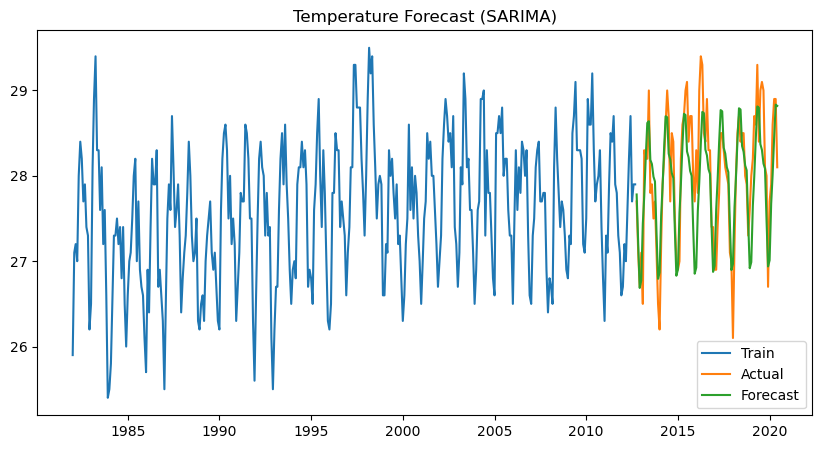

In [22]:
# Plot results
plt.figure(figsize=(10,5))
plt.plot(train.index, train['mean_temp'], label='Train')
plt.plot(test.index, test['mean_temp'], label='Actual')
plt.plot(test.index, forecast, label='Forecast')

plt.legend()
plt.title("Temperature Forecast (SARIMA)")
plt.show()

In [23]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test['mean_temp'], forecast)
print("MAE:", mae)

MAE: 0.3830684977043152


In [24]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(test['mean_temp'], forecast))
print("RMSE:", rmse)

RMSE: 0.48087443447041206


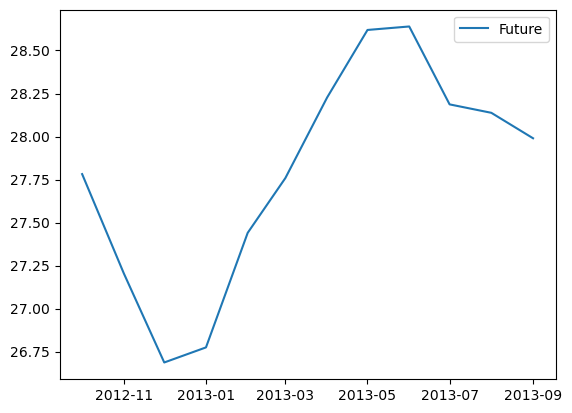

In [25]:
future = model_fit.forecast(steps=12)

plt.plot(future, label='Future')
plt.legend()
plt.show()

# Conclusion
## Processed monthly temperature data (462 records) and set datetime index for time series analysis.
## Verified stationarity using ADF test and confirmed no differencing was required.
## Built a SARIMA model with seasonal components using time-based train-test split.
## Evaluated performance using MAE (0.38°C) and RMSE (0.48°C), showing high accuracy.
## Generated future temperature forecasts for the next 12 months using the trained model.